# Score de risque CG10 — Prédiction d'un éclair nuage-sol dans les 10 prochaines minutes

## Contexte

Dans le cadre de la sécurité aéroportuaire, la foudre de type **nuage-sol (CG)** représente un danger direct pour les opérations au sol. L'objectif de ce notebook est de construire un **score de risque** permettant d'anticiper la survenue d'un tel éclair dans les **10 prochaines minutes** à proximité d'un aéroport (≤ 20 km).

Ce score, fondé sur l'historique récent de l'activité orageuse, doit être :
- **Discriminant** : distinguer les situations à risque des situations calmes
- **Stable** : performant sur des périodes non vues (OOT 2022)
- **Lisible** : interprétable par les opérationnels via des Classes Homogènes de Risque (CHR)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

Les données météo pré-traitées sont chargées depuis le fichier pickle produit par la phase de feature engineering. Ce fichier contient le DataFrame enrichi (`df`), la liste des variables candidates (`VAR`), les dummies et les identifiants.

In [14]:
import joblib
path = '..\\data\\meteo_data_clipped.pkl'
meteo_data = joblib.load(path)

In [15]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [16]:
df = meteo_data['df']
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

In [17]:

# 1️⃣ identifier les éclairs cloud-ground dans 3 km
df["cg_3km"] = (
    (~df["icloud"]) &
    (df["dist"] <= 3)
)

# 2️⃣ créer une colonne avec date seulement pour ces événements
df["cg3_date"] = df["date"].where(df["cg_3km"])

# 3️⃣ prochain événement dans chaque aéroport
df["next_cg3_date"] = (
    df.groupby("airport")["cg3_date"]
    .bfill()
)

# 4️⃣ temps jusqu'au prochain éclair
df["time_to_next_cg3"] = (
    df["next_cg3_date"] - df["date"]
).dt.total_seconds()

df["time_to_next_cg3"]  = df["time_to_next_cg3"].clip(0,3600)
# 5️⃣ supprimer les lignes sans événement futur
df = df[df["time_to_next_cg3"].notna()]



## 2. Exploration de la variable cible `time_to_next_cg20`

Avant de définir la cible binaire, on analyse la distribution du **temps jusqu'au prochain CG ≤ 20 km**. La distribution est très asymétrique (médiane ~47 s, mais 90e percentile à 35 min), ce qui justifie le choix d'un seuil court de **10 minutes** pour capturer les situations à risque immédiat.

In [18]:
df['time_to_next_cg3'].quantile([0.84, 0.85, 0.86, 0.87, 0.88, 0.89,0.90,0.95,0.99])


0.84    3600.0
0.85    3600.0
0.86    3600.0
0.87    3600.0
0.88    3600.0
0.89    3600.0
0.90    3600.0
0.95    3600.0
0.99    3600.0
Name: time_to_next_cg3, dtype: float64

In [19]:
df['time_to_next_cg3'].describe()

count    505754.000000
mean       2608.895342
std        1382.236235
min           0.000000
25%        1171.000000
50%        3600.000000
75%        3600.000000
max        3600.000000
Name: time_to_next_cg3, dtype: float64

## 3. Définition de la cible binaire

**Formulation du problème de scoring** : pour chaque éclair observé, on veut prédire si un éclair CG surviendra dans les **10 prochaines minutes** à moins de 20 km de l'aéroport.

$$\text{next\_10min\_cg20} = \mathbb{1}[\text{time\_to\_next\_cg20} > 10 \text{ min}]$$

- `True` = **risque faible** (pas de CG dans les 10 prochaines minutes)
- `False` = **risque actif** (CG imminent)

> Note : la variable est définie comme "absence de CG" pour aligner la convention avec un score croissant.

In [20]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_10min_cg3'] = df['time_to_next_cg3'] > (10 * 60) # LE prochain arrive dans moins de 10 minutes


In [21]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_15min_cg3'] = df['time_to_next_cg3'] <= (15 * 60) # LE prochain arrive dans moins de 15 minutes
df['next_15min_cg3'].value_counts()

next_15min_cg3
False    396187
True     109567
Name: count, dtype: int64

In [22]:
df.groupby("season")["next_15min_cg3"].mean()

season
Automne      0.238110
Hiver        0.080523
Printemps    0.122993
Été          0.228639
Name: next_15min_cg3, dtype: float64

## 2. Construction de la cible binaire

On discrétise `time_to_next_cg20` avec le seuil à **15 minutes (900 secondes)**.

Le déséquilibre (~90% / 10%) est caractéristique des problèmes d'alerte :
la majorité du temps, un CG arrive dans les 15 minutes car les éclairs se produisent en rafales.
La classe rare (pas de CG imminent) est précisément ce que le score doit détecter.

Prévalence (pas de CG dans 15 min) : 21.66%
next_15min_cg3
False    396187
True     109567
Name: count, dtype: int64


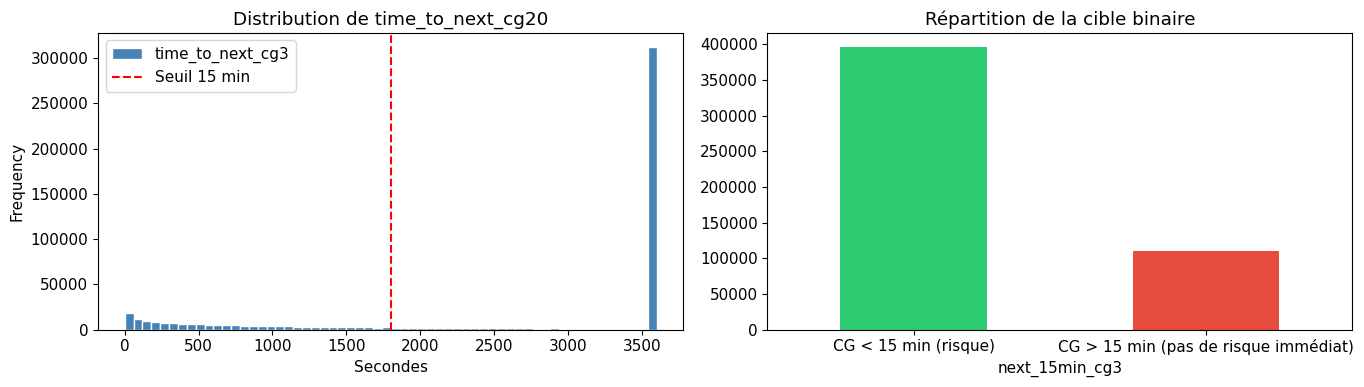

In [23]:
target_col = 'next_15min_cg3'
prevalence = df[target_col].mean()
print(f'Prévalence (pas de CG dans 15 min) : {prevalence:.2%}')
print(df[target_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['time_to_next_cg3'].plot.hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(1800, color='red', linestyle='--', label='Seuil 15 min')
axes[0].set_title('Distribution de time_to_next_cg20')
axes[0].set_xlabel('Secondes')
axes[0].legend()

df[target_col].value_counts().plot.bar(ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Répartition de la cible binaire')
axes[1].set_xticklabels(['CG < 15 min (risque)', 'CG > 15 min (pas de risque immédiat)'], rotation=0)
plt.tight_layout()
plt.show()

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




### Découpage temporel

- **Train** : 2015–2021, 70 % aléatoire stratifié — sert à l'entraînement et à la calibration des hyperparamètres
- **Test** : 2015–2021, 15 % restant — évaluation interne
- **OOT** : 2022 — données hors-temps, jamais vues lors du développement, servent de validation finale

In [24]:
from sklearn.model_selection import train_test_split

data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2021)
stratify_col = (data[target_col].astype(str)+ "_" + data['airport'] + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.2, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2022].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((343496, 114), (85874, 114), (76384, 114))

### Préparation des matrices X / y

On sépare les features (`VAR` + variables catégorielles encodées one-hot : `airport`, `season`) de la cible. L'encodage est aligné entre les trois jeux pour éviter tout décalage de colonnes.

In [25]:
X_train = train_data[VAR+["airport",'season']].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[VAR+["airport",'season']].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[VAR+["airport",'season']].copy()
y_oot = oot_data[target_col].copy()*1

# IMPUTATION

In [26]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit sur train uniquement
X_train[VAR] = imputer.fit_transform(X_train[VAR])

# Transform sur test et OOT avec les médianes du train
X_test[VAR] = imputer.transform(X_test[VAR])
X_oot[VAR]  = imputer.transform(X_oot[VAR])

print("Médianes utilisées :")
print(dict(zip(VAR+["airport",'season'], imputer.statistics_)))


Médianes utilisées :
{'min_dist_5min': np.float64(6.312312543059179), 'time_since_last_CG20_2': np.float64(3.828641396489095), 'log_count_30min': np.float64(5.717027701406222), 'amplitude_change': np.float64(0.039431292998906686), 'activity_decay': np.float64(1.0526315173899696), 'time_since_last_intra_cloud2': np.float64(1.6094379124341003), 'log_cg_count_10min': np.float64(3.1780538303479458), 'min_dist_1min': np.float64(10.587577258695642), 'cg_20km': np.float64(0.0), 'log_std_amplitude_10min': np.float64(2.3390168857999125), 'is_cloud_ground': np.float64(0.0), 'log_cg_count_20min': np.float64(3.7612001156935624), 'burst_indicator': np.float64(1.0), 'hour': np.float64(13.0), 'storm_direction_change': np.float64(3.0238506933921103), 'time_since_last_cloud_ground2': np.float64(2.833213344056216), 'std_lat_10min': np.float64(0.07465553097485156), 'mean_dist_1min': np.float64(20.572487187985587), 'dist': np.float64(21.358985116346872), 'log_count_5min': np.float64(4.174387269895637), 'a

## 4. Sélection des variables candidates

Les variables sont pré-sélectionnées selon leur importance SHAP issue d'un premier modèle benchmark, en favorisant :
- l'**activité récente** (comptages log sur 5, 10, 20 min)
- la **distance minimale** (indicateur de proximité)
- la **dispersion angulaire** (étalement de l'orage)
- les **délais** depuis le dernier CG (inertie orageuse)

In [31]:
top_var = ['min_dist_10min', 'min_dist_1min', 'log_cg_count_10min', 'log_cg_count_5min', 
           'log_count_5min', 'log_count_10min', 'log_cg_count_20min', 'std_azimuth_1min', 
           'mean_dist_5min', 'log_count_20min', 'std_azimuth_10min', 'rate_trend', 'mean_dist_1min', 
           'log_count_1min', 'storm_spread', 'mean_dist_10min', 'log_ic_count_5min',
             'log_ic_count_10min', 'log_ic_count_20min', 'std_lon_10min', 'std_lat_10min', 
             'time_since_last_lightning2', 'burst_indicator', 'time_since_last_cloud_ground2', 'activity_decay', 
             'max_amplitude_10min', 'dist', 'max_amplitude_1min', 'mean_azimuth_1min', 'mean_azimuth_10min',
               'storm_direction_change', 'distance_trend', 'season', 'cg_20km', 'alert_duration', 'azimuth', 'azimuth_change']
len(top_var)

37

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_vars = top_var
#  = ['log_cg_count_5min', 'log_count_5min', 'log_cg_count_10min',
#        'mean_dist_5min', 'cg_20km', 'min_dist_1min', 'log_count_1min',
#        'min_dist_5min', 'log_ic_count_5min', 'mean_dist_10min',
#        'mean_dist_1min', 'hour', 'log_cg_count_20min', 'storm_spread',
#        'min_dist_10min', 'mean_azimuth_10min', 'log_count_15min',
#        'mean_azimuth_1min', 'time_since_last_lightning2',
#        'storm_center_distance']#VAR+["airport",'season'] 

X_train = train_data[xgb_vars].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[xgb_vars].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[xgb_vars].copy()
y_oot = oot_data[target_col].copy()*1
combined = pd.concat([X_train, X_test,X_oot], keys=['train', 'test','oot'])
combined_enc = pd.get_dummies(combined)

#Séparer avec les mêmes colonnes
X_train_enc = combined_enc.xs('train')#
X_test_enc = combined_enc.xs('test')
X_oot_enc = combined_enc.xs('oot')



## 5. Modèle XGBoost

On entraîne un **XGBClassifier** (`binary:logistic`) avec les hyperparamètres optimisés par **Optuna** (50 trials, 3-fold CV stratifié sur le train). L'algorithme histogram (`tree_method=hist`) accélère l'entraînement sur ce volume de données (~350 k lignes).

In [33]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "objective":        "binary:logistic",
        "eval_metric":      "auc",
        "tree_method":      "hist",
        "random_state":     42,
        "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":            trial.suggest_float("gamma", 0, 15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }

    model = XGBClassifier(**params,eval_set=[(X_test_enc, y_test)])
    scores = cross_val_score(model, X_train_enc, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"Meilleur AUC CV : {study.best_value:.4f}")
print("Meilleurs paramètres :")
study.best_params


Best trial: 12. Best value: 0.997624: 100%|██████████| 15/15 [15:10<00:00, 60.71s/it]

Meilleur AUC CV : 0.9976
Meilleurs paramètres :


{'n_estimators': 340,
 'max_depth': 7,
 'learning_rate': 0.18630628262434443,
 'subsample': 0.9870394487089063,
 'colsample_bytree': 0.6786921576593067,
 'gamma': 1.2540924325081915,
 'min_child_weight': 15,
 'reg_alpha': 0.008397656439471051,
 'reg_lambda': 0.06342656422775246}

### Hyperparamètres optimisés (Optuna — 3-fold CV)

Les paramètres ci-dessous ont été sélectionnés pour **maximiser le ROC AUC** en validation croisée stratifiée. La régularisation L1/L2 (`reg_alpha`, `reg_lambda`) et `min_child_weight` élevé limitent le surapprentissage.

In [34]:
params = {'n_estimators': 340,
 'max_depth': 7,
 'learning_rate': 0.18630628262434443,
 'subsample': 0.9870394487089063,
 'colsample_bytree': 0.6786921576593067,
 'gamma': 1.2540924325081915,
 'min_child_weight': 15,
 'reg_alpha': 0.008397656439471051,
 'reg_lambda': 0.06342656422775246}

model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    **params
)
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_test_enc, y_test)], verbose=False)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6786921576593067
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## 6. Évaluation des performances

Métriques calculées sur les trois jeux :

| Métrique | Description |
|---|---|
| **ROC AUC** | Discrimination globale (insensible au seuil) |
| **Gini** | 2 × AUC − 1, normalisé entre 0 et 1 |
| **PR AUC** | AUC de la courbe Précision-Rappel, adaptée aux classes déséquilibrées |
| **Ratio RP** | PR AUC / prévalence — un modèle aléatoire vaut 1.0 |

In [35]:
from sklearn.metrics import average_precision_score
y_pred = model_xgb.predict(X_oot_enc)
print(classification_report(y_oot, y_pred))

proba_train = model_xgb.predict_proba(X_train_enc)[:, 1]
proba_test  = model_xgb.predict_proba(X_test_enc)[:, 1]
proba_oot  = model_xgb.predict_proba(X_oot_enc)[:, 1]

prevalence = y_test.mean()

auc_train   = roc_auc_score(y_train, proba_train)
gini_train  = 2 * auc_train - 1

auc_test    = roc_auc_score(y_test, proba_test)
auc_pr_test = average_precision_score(y_test, proba_test)
rp          = auc_pr_test / prevalence
gini_test  = 2 * auc_test - 1

auc_oot    = roc_auc_score(y_oot, proba_oot)
auc_pr_oot = average_precision_score(y_oot, proba_oot)
rp_o          = auc_pr_oot / y_oot.mean()
gini_oot  = 2 * auc_oot - 1
print(f"ROC AUC TRAIN: {auc_train:.4f}  |  Gini TRAIN: {gini_train:.4f}")
print(f"ROC AUC TEST:  {auc_test:.4f} |  Gini Test: {gini_test:.4f}")
print(f"PR AUC TEST:   {auc_pr_test:.4f}  |  Ratio RP: {rp:.4f}")
print(f"ROC AUC OOT:  {auc_oot:.4f} |  Gini OOT: {gini_oot:.4f}")
print(f"PR AUC OOT:   {auc_pr_oot:.4f}  |  Ratio RP OOT: {rp_o:.4f}")


              precision    recall  f1-score   support

           0       0.88      0.95      0.91     61187
           1       0.71      0.47      0.56     15197

    accuracy                           0.86     76384
   macro avg       0.79      0.71      0.74     76384
weighted avg       0.84      0.86      0.84     76384

ROC AUC TRAIN: 0.9995  |  Gini TRAIN: 0.9991
ROC AUC TEST:  0.9984 |  Gini Test: 0.9968
PR AUC TEST:   0.9966  |  Ratio RP: 4.5350
ROC AUC OOT:  0.8753 |  Gini OOT: 0.7505
PR AUC OOT:   0.6339  |  Ratio RP OOT: 3.1860


### Calcul des scores (probabilités × 1000)

On transforme les probabilités brutes en **points** entre 0 et 1000. Un point élevé indique un risque élevé de CG dans les 10 prochaines minutes. Cette mise à l'échelle facilite la lecture opérationnelle et la construction des CHR.

In [36]:
test_data['probas'] = proba_test
train_data['probas'] = proba_train
oot_data['probas'] = proba_oot
test_data['points'] = proba_test*1000
train_data['points'] = proba_train*1000
oot_data['points'] = proba_oot*1000

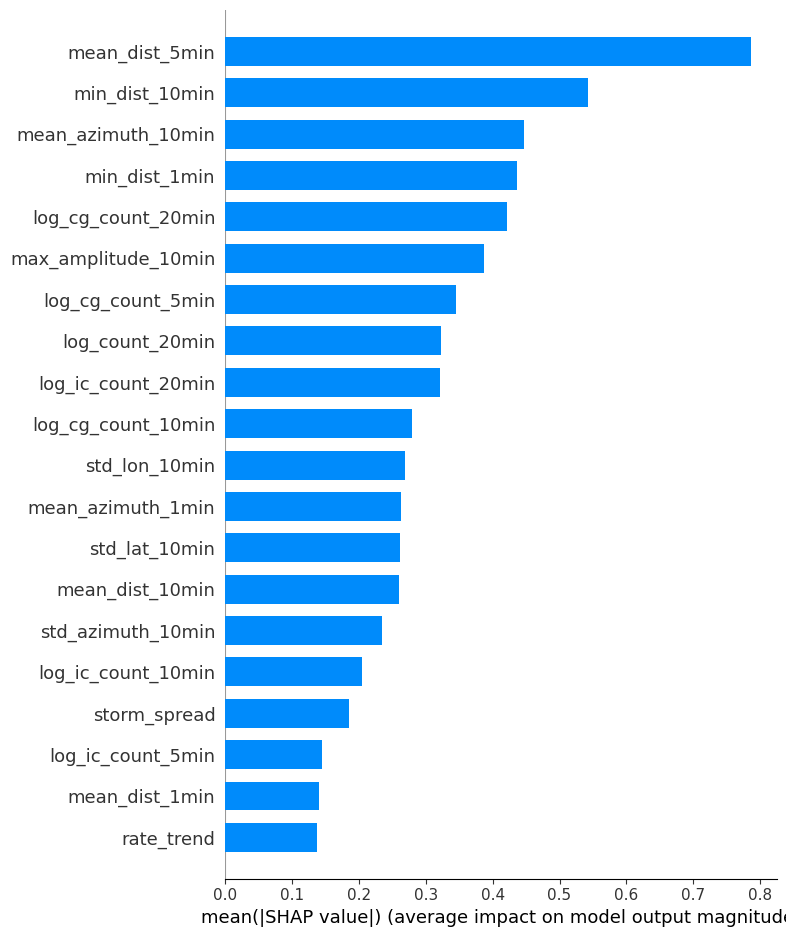

In [37]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_train_enc)

shp = shap.summary_plot(shap_values, X_train_enc, plot_type="bar")


In [38]:
# Importance = moyenne des |valeurs SHAP|
importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_train_enc.columns
).sort_values(ascending=False)

print(importance.to_string())

mean_dist_5min                   0.785879
min_dist_10min                   0.542470
mean_azimuth_10min               0.446273
min_dist_1min                    0.437102
log_cg_count_20min               0.421014
max_amplitude_10min              0.387659
log_cg_count_5min                0.344818
log_count_20min                  0.322913
log_ic_count_20min               0.320828
log_cg_count_10min               0.279684
std_lon_10min                    0.268362
mean_azimuth_1min                0.263212
std_lat_10min                    0.261860
mean_dist_10min                  0.260183
std_azimuth_10min                0.234570
log_ic_count_10min               0.204346
storm_spread                     0.185519
log_ic_count_5min                0.144225
mean_dist_1min                   0.139683
rate_trend                       0.137204
distance_trend                   0.132051
log_count_10min                  0.126097
log_count_5min                   0.117137
activity_decay                   0

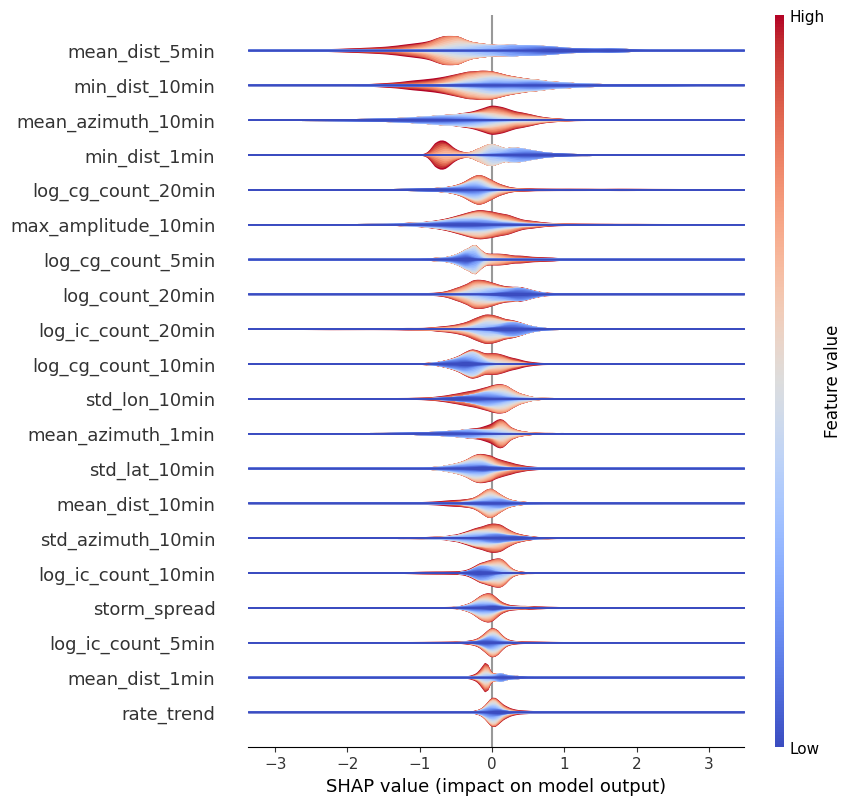

In [39]:
feat_names = X_train_enc.columns.tolist()
shap.plots.violin(
    shap_values,
    features=X_train_enc,
    feature_names=feat_names,
    plot_type="layered_violin",
    max_display=20  # Limite à 20 variables les plus importantes
)

# Analyse des performances

In [40]:
import sys
import os
from importlib import reload
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import analyser
from importlib import reload
reload(analyser)
train_analyser= analyser.Analyser(X=train_data,target_col=target_col)
test_analyser= analyser.Analyser(X=test_data,target_col=target_col)
oot_analyser= analyser.Analyser(X=test_data,target_col=target_col)

## AUC maské

In [41]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


### par aeroport

In [42]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [43]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,22592,0.191130,0.998799,0.997598,0.997156,5.217174
Pise,27039,0.213913,0.998439,0.996877,0.996530,4.658572
Biarritz,19171,0.220437,0.998890,0.997780,0.997810,4.526508
Nantes,5828,0.227351,0.998792,0.997584,0.997708,4.388411
Ajaccio,11244,0.286286,0.996062,0.992125,0.993497,3.470296


In [44]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Biarritz,19237,0.100172,0.824344,0.648688,0.457889,4.571053
Pise,20642,0.232875,0.927486,0.854972,0.802992,3.448173
Nantes,7423,0.233868,0.869279,0.738559,0.674926,2.885933
Bastia,12812,0.241570,0.877049,0.754097,0.619344,2.563822
Ajaccio,16270,0.223233,0.810206,0.620413,0.550338,2.465307


### par saison

In [45]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Hiver,2102,0.071361,0.978852,0.957705,0.893615,12.522524
Printemps,8454,0.095813,0.992231,0.984463,0.973206,10.157391
Été,47618,0.234722,0.999053,0.998106,0.998046,4.252031
Automne,27700,0.243141,0.998293,0.996586,0.996882,4.100020


In [46]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,12348,0.181568,0.886955,0.773911,0.695472,3.830372
Été,50431,0.199897,0.880736,0.761472,0.638756,3.195426
Hiver,875,0.184000,0.799094,0.598187,0.566995,3.081495
Printemps,12730,0.213119,0.858114,0.716227,0.588710,2.762360


## 8. Analyse restreinte aux éclairs CG ≤ 20 km

On analyse les performances et la stabilité des CHR **uniquement sur les éclairs nuage-sol proches** (CG ≤ 20 km), qui constituent la population la plus exposée au risque opérationnel direct.

In [91]:
auc_mask(test_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
False,76234,0.207781,0.998553,0.997106,0.996941,4.798031
True,9640,0.314523,0.996393,0.992786,0.994420,3.161677


In [92]:
auc_mask(oot_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
False,67970,0.177902,0.880019,0.760038,0.620665,3.488802
True,8414,0.369028,0.803804,0.607609,0.687149,1.862053


## KS stat

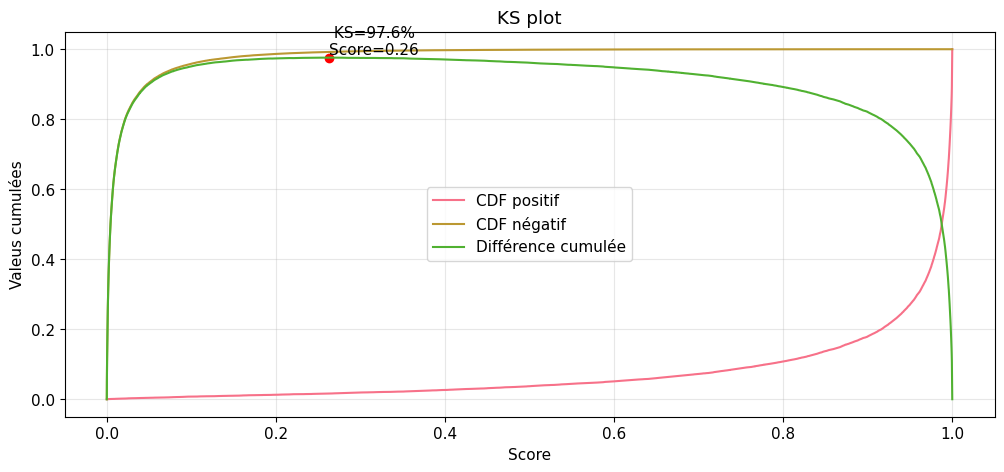

Discrimination forte (KS > 70%)


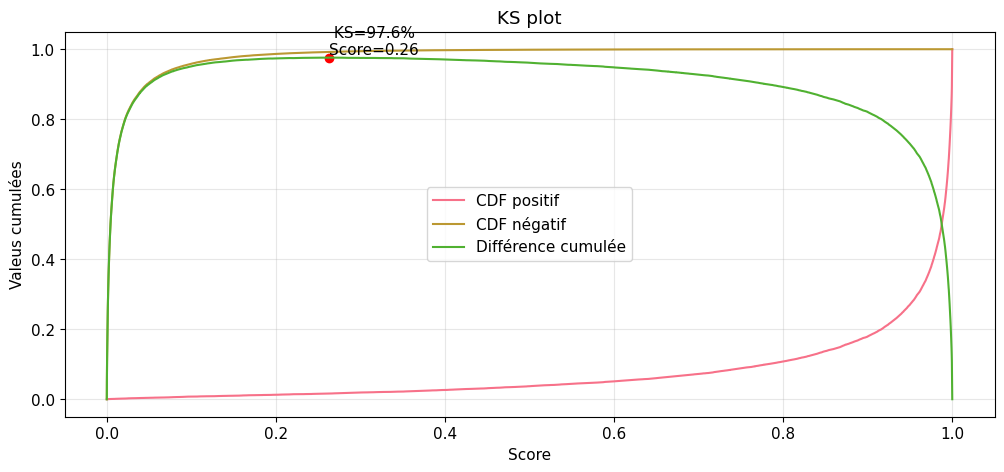

Discrimination forte (KS > 70%)


In [49]:
test_analyser.plot_ks()
oot_analyser.plot_ks()

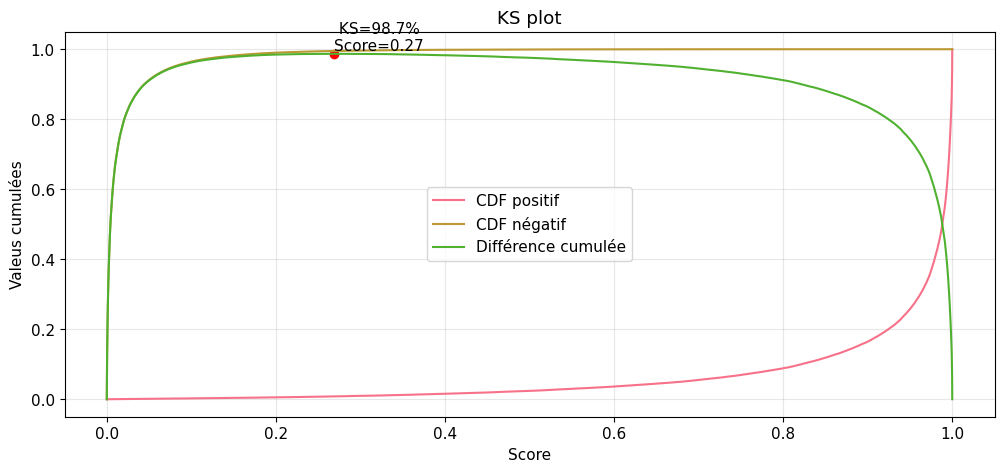

Discrimination forte (KS > 70%)


In [50]:
train_analyser.plot_ks()

## Reliability diagrams

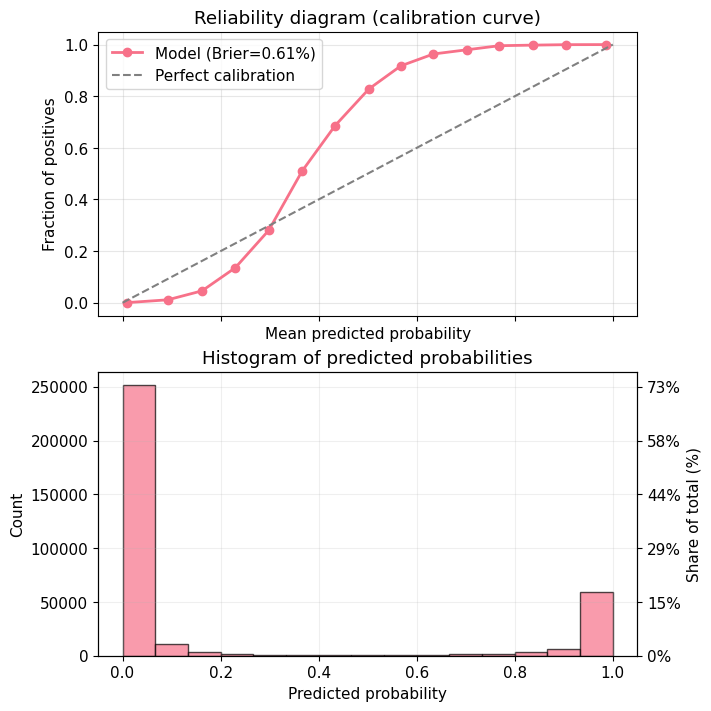

In [51]:
train_analyser.reliability_diagram(n_bins=15)

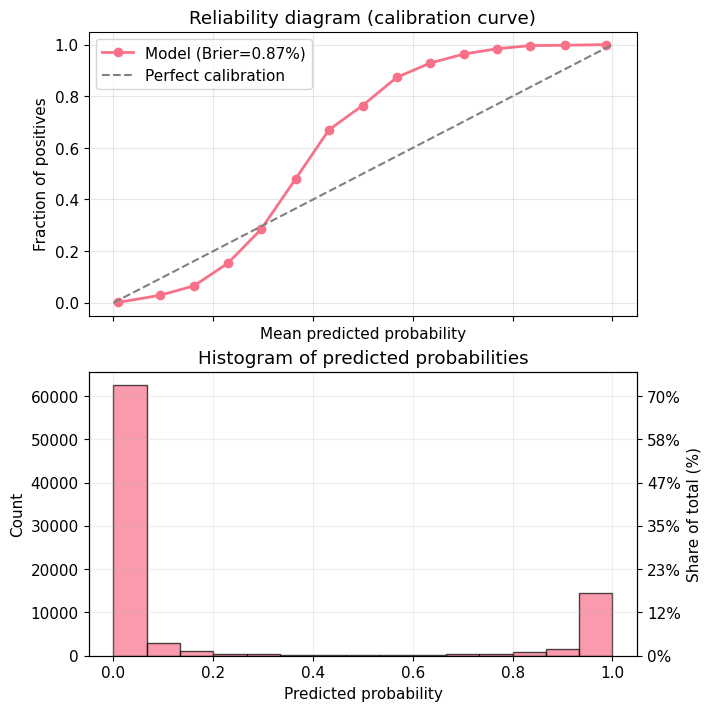

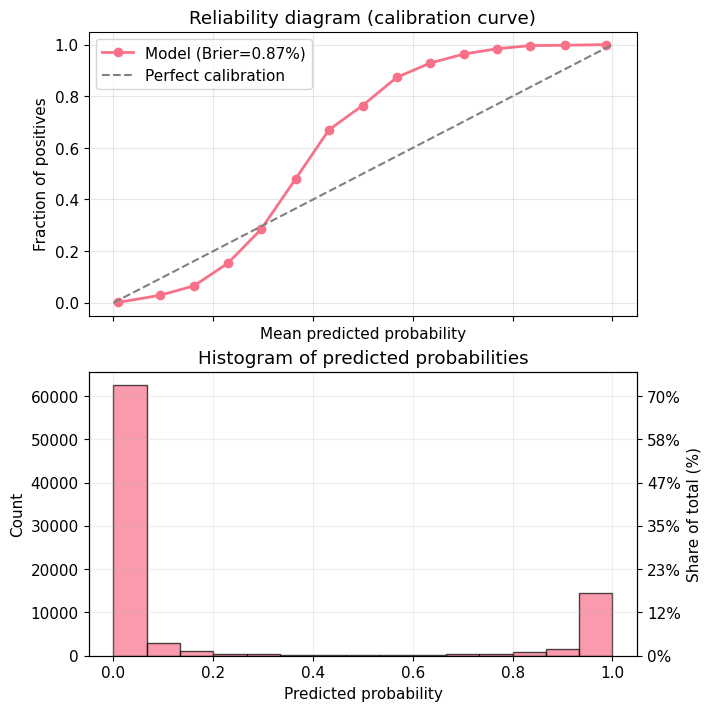

In [52]:
test_analyser.reliability_diagram(n_bins=15)
oot_analyser.reliability_diagram(n_bins=15)

## quelques plots

### Distribution des scores par classe

Les graphiques empilés montrent la répartition des **bons** (pas de CG < 10 min) et **mauvais** (CG < 10 min) selon les intervalles de score. Un bon score présente une séparation nette des deux populations : les mauvais se concentrent sur les scores élevés.

In [53]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#e74c3c','#2ecc71'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['CG20 imminent', 'Last CG20'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of last CG by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



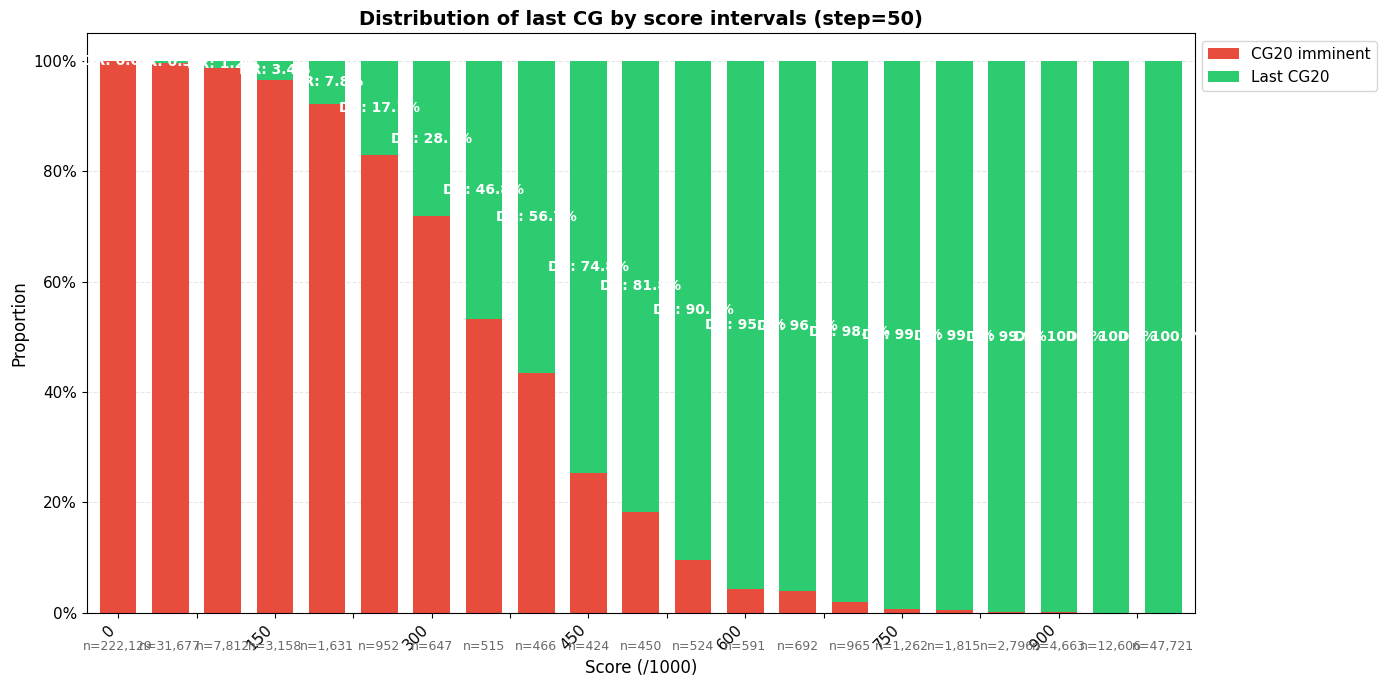


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0 222129       222082       47        0.02%
    50  31677        31585       92        0.29%
   100   7812         7717       95        1.22%
   150   3158         3050      108        3.42%
   200   1631         1504      127        7.79%
   250    952          789      163       17.12%
   300    647          465      182       28.13%
   350    515          274      241       46.80%
   400    466          202      264       56.65%
   450    424          107      317       74.76%
   500    450           82      368       81.78%
   550    524           50      474       90.46%
   600    591           25      566       95.77%
   650    692           27      665       96.10%
   700    965           18      947       98.13%
   750   1262            9     1253       99.29%
   800   1815            7     1808       99.61%
   850   2796            2     2794       99.93%
   900   4663            2     4661       

In [54]:
score_graph_empile(train_data, score_col='points', label_col=target_col, pas=50)
#probas_graph_empile(train_data, score_col='points', label_col='default_t_plus_1', pas=0.05)

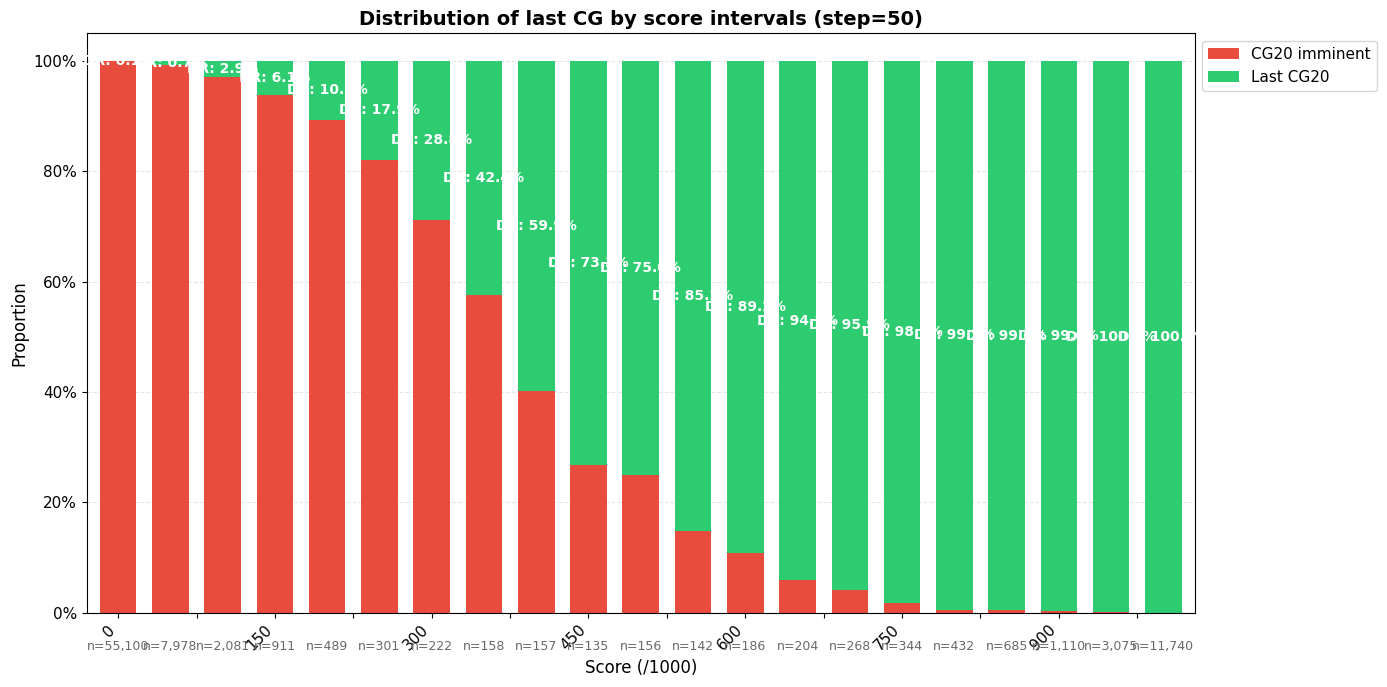


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  55100        55053       47        0.09%
    50   7978         7922       56        0.70%
   100   2081         2021       60        2.88%
   150    911          855       56        6.15%
   200    489          437       52       10.63%
   250    301          247       54       17.94%
   300    222          158       64       28.83%
   350    158           91       67       42.41%
   400    157           63       94       59.87%
   450    135           36       99       73.33%
   500    156           39      117       75.00%
   550    142           21      121       85.21%
   600    186           20      166       89.25%
   650    204           12      192       94.12%
   700    268           11      257       95.90%
   750    344            6      338       98.26%
   800    432            2      430       99.54%
   850    685            3      682       99.56%
   900   1110            4     1106       

In [55]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


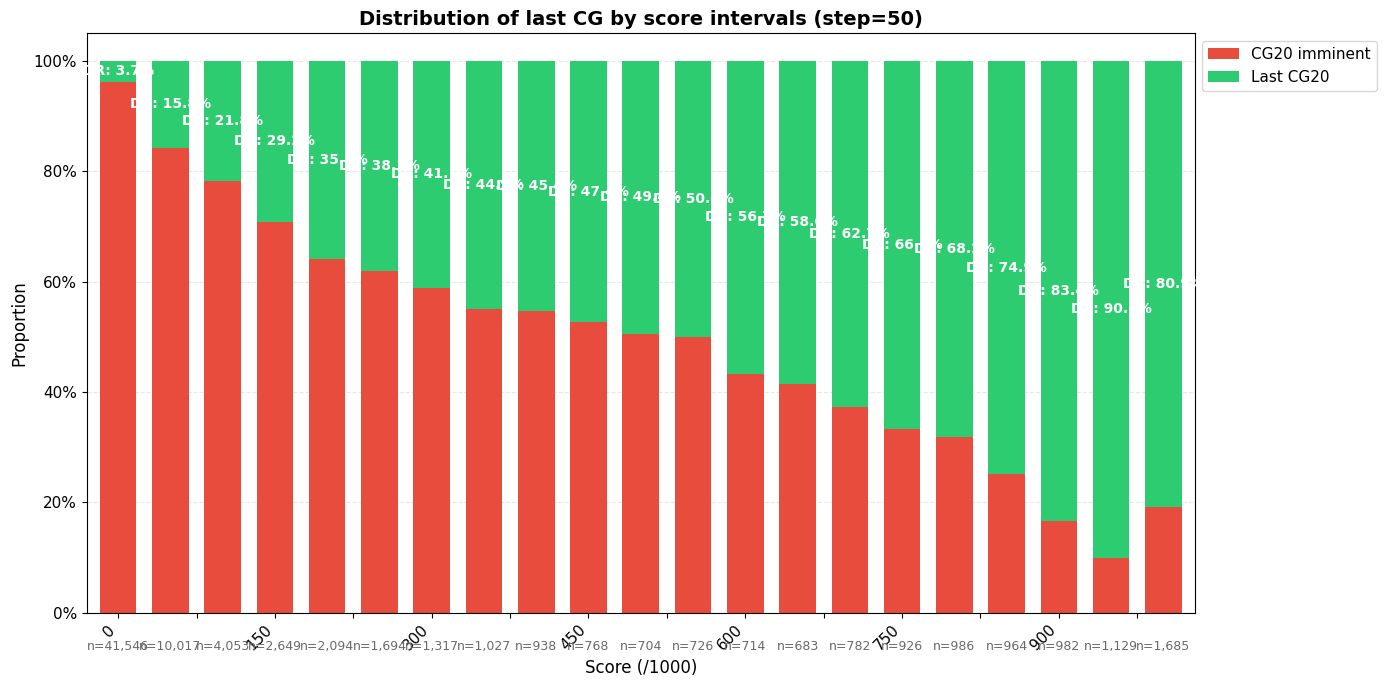


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  41546        39992     1554        3.74%
    50  10017         8436     1581       15.78%
   100   4053         3169      884       21.81%
   150   2649         1876      773       29.18%
   200   2094         1342      752       35.91%
   250   1694         1049      645       38.08%
   300   1317          776      541       41.08%
   350   1027          566      461       44.89%
   400    938          512      426       45.42%
   450    768          404      364       47.40%
   500    704          356      348       49.43%
   550    726          363      363       50.00%
   600    714          309      405       56.72%
   650    683          283      400       58.57%
   700    782          292      490       62.66%
   750    926          309      617       66.63%
   800    986          314      672       68.15%
   850    964          242      722       74.90%
   900    982          163      819       

In [56]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


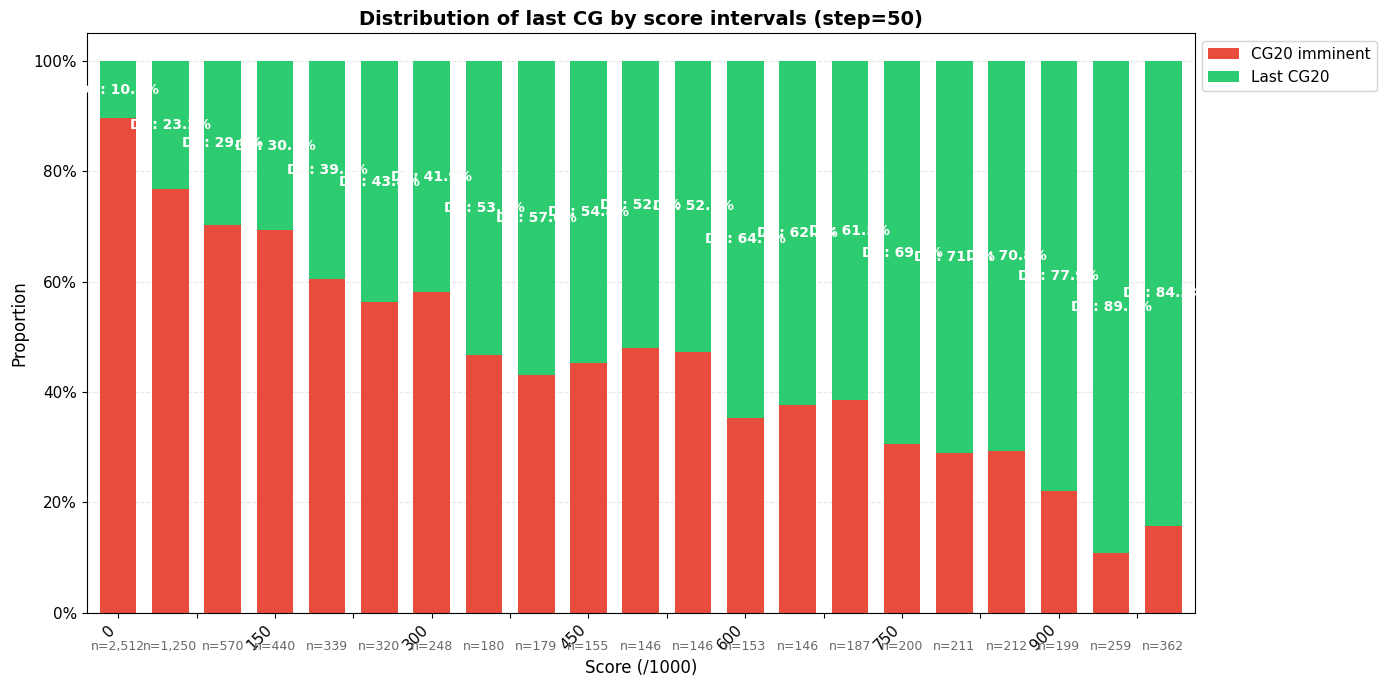


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0   2512         2251      261       10.39%
    50   1250          960      290       23.20%
   100    570          400      170       29.82%
   150    440          305      135       30.68%
   200    339          205      134       39.53%
   250    320          180      140       43.75%
   300    248          144      104       41.94%
   350    180           84       96       53.33%
   400    179           77      102       56.98%
   450    155           70       85       54.84%
   500    146           70       76       52.05%
   550    146           69       77       52.74%
   600    153           54       99       64.71%
   650    146           55       91       62.33%
   700    187           72      115       61.50%
   750    200           61      139       69.50%
   800    211           61      150       71.09%
   850    212           62      150       70.75%
   900    199           44      155       

In [57]:
score_graph_empile(oot_data.loc[oot_data['cg_20km']], score_col='points', label_col=target_col, pas=50)


## 7. Construction des Classes Homogènes de Risque (CHR)

Les CHR regroupent des intervalles de score présentant un **niveau de risque homogène** et un **volume suffisant**. On utilise une pré-discrétisation **Jenks** (minimisation de la variance intra-classe) puis des fusions manuelles pour assurer :

- La **monotonicité** du taux de CG par classe (risque croissant avec le score)
- La **stabilité temporelle** — PSI faible entre train, test et OOT
- Un **volume minimal** par classe (≥ 1 % du portefeuille)

Les CHR constituent la livrables principale du score : chaque éclair est affecté à une classe de risque opérationnelle.

# Première approche, trouver un seuil

## Seuil optimal F1

In [58]:
from sklearn.metrics import f1_score, precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, proba_train)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Seuil optimal F1 : {best_threshold:.3f} | F1 : {f1_scores.max():.4f}")


Seuil optimal F1 : 0.354 | F1 : 0.9896


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     67002
           1       0.99      0.98      0.98     18872

    accuracy                           0.99     85874
   macro avg       0.99      0.99      0.99     85874
weighted avg       0.99      0.99      0.99     85874



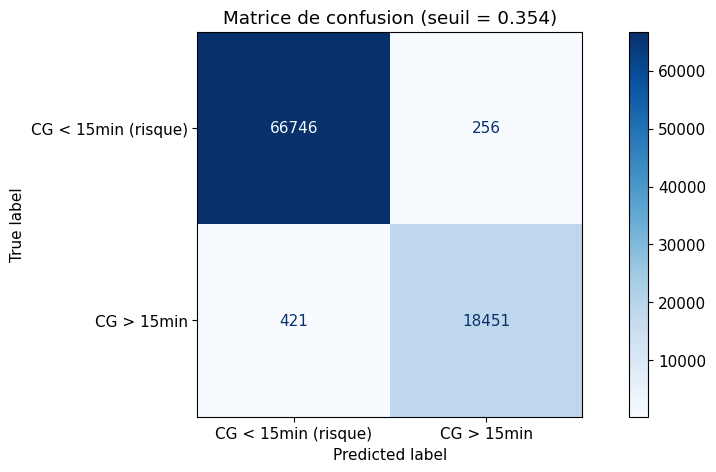

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = (proba_test > best_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 15min (risque)', 'CG > 15min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


              precision    recall  f1-score   support

           0       0.89      0.93      0.91     61187
           1       0.66      0.54      0.59     15197

    accuracy                           0.85     76384
   macro avg       0.78      0.73      0.75     76384
weighted avg       0.84      0.85      0.85     76384



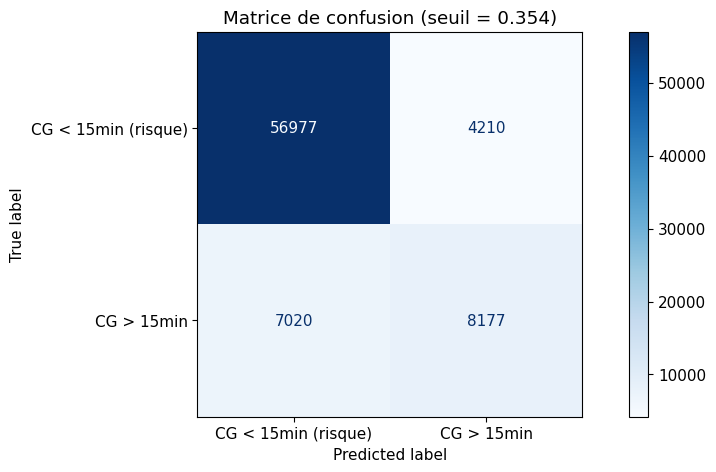

In [60]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = (proba_oot > best_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 15min (risque)', 'CG > 15min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


## Seuil optimal Youden

In [61]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, proba_train)
youden = tpr - fpr
best_threshold = thresholds[youden.argmax()]
print(f"Seuil optimal Youden : {best_threshold:.3f}")


Seuil optimal Youden : 0.268


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     67002
           1       0.97      0.98      0.98     18872

    accuracy                           0.99     85874
   macro avg       0.98      0.99      0.99     85874
weighted avg       0.99      0.99      0.99     85874



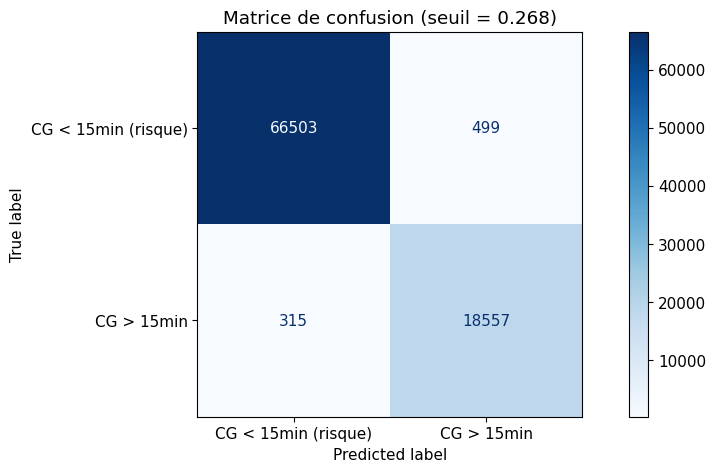

In [62]:
pred = (proba_test > best_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 15min (risque)', 'CG > 15min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


              precision    recall  f1-score   support

           0       0.90      0.91      0.91     61187
           1       0.63      0.60      0.61     15197

    accuracy                           0.85     76384
   macro avg       0.76      0.75      0.76     76384
weighted avg       0.85      0.85      0.85     76384



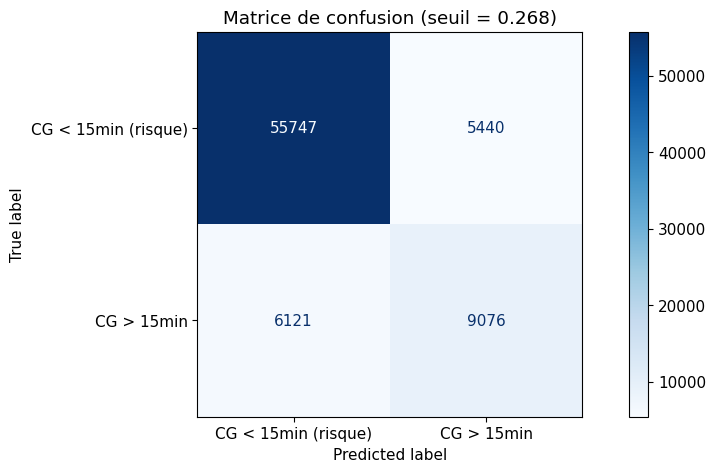

In [63]:
pred = (proba_oot > best_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 15min (risque)', 'CG > 15min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


## Recall et precision 

Seuil max précision (rappel ≥ 15%) : 0.936
  Précision : 1.0000
  Rappel    : 0.7637

Seuil max rappel (précision ≥ 15%) : 0.000
  Précision : 0.2198
  Rappel    : 1.0000


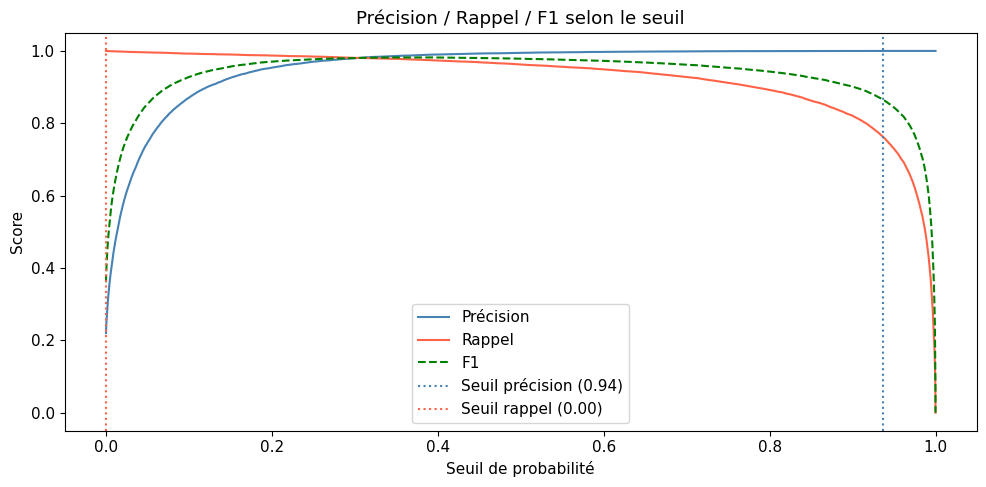

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

# Seuil qui maximise la précision (minimise les fausses alarmes)
# Contrainte : rappel minimum acceptable (ex : 15%)
min_recall = 0.15
mask = recall[:-1] >= min_recall
if mask.any():
    best_precision_threshold = thresholds[mask][precision[:-1][mask].argmax()]
    print(f"Seuil max précision (rappel ≥ {min_recall:.0%}) : {best_precision_threshold:.3f}")
    print(f"  Précision : {precision_score(y_test, proba_test >= best_precision_threshold):.4f}")
    print(f"  Rappel    : {recall_score(y_test, proba_test >= best_precision_threshold):.4f}")

# Seuil qui maximise le rappel (minimise les CG manqués)
# Contrainte : précision minimum acceptable (ex : 15%)
min_precision = 0.15
mask = precision[:-1] >= min_precision
if mask.any():
    best_recall_threshold = thresholds[mask][recall[:-1][mask].argmax()]
    print(f"\nSeuil max rappel (précision ≥ {min_precision:.0%}) : {best_recall_threshold:.3f}")
    print(f"  Précision : {precision_score(y_test, proba_test >= best_recall_threshold):.4f}")
    print(f"  Rappel    : {recall_score(y_test, proba_test >= best_recall_threshold):.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Précision', color='steelblue')
plt.plot(thresholds, recall[:-1],    label='Rappel',    color='tomato')
plt.plot(thresholds, 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9),
         label='F1', color='green', linestyle='--')
plt.axvline(best_precision_threshold, color='steelblue', linestyle=':', label=f'Seuil précision ({best_precision_threshold:.2f})')
plt.axvline(best_recall_threshold,    color='tomato',    linestyle=':', label=f'Seuil rappel ({best_recall_threshold:.2f})')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Score')
plt.title('Précision / Rappel / F1 selon le seuil')
plt.legend()
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     67002
           1       1.00      0.76      0.87     18872

    accuracy                           0.95     85874
   macro avg       0.97      0.88      0.92     85874
weighted avg       0.95      0.95      0.95     85874



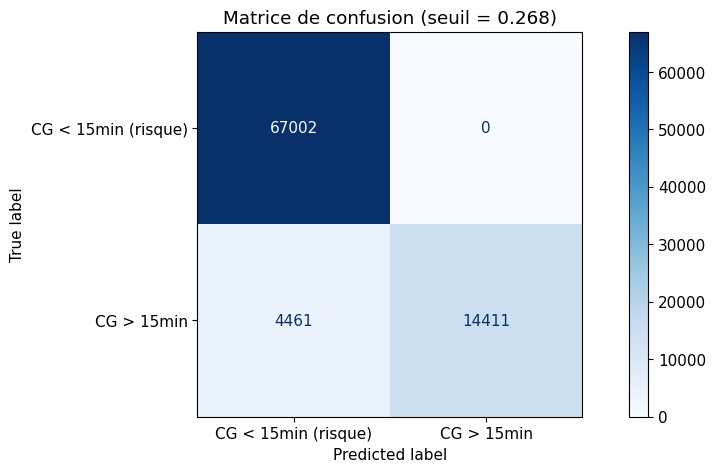

In [65]:
pred = (proba_test > best_precision_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 15min (risque)', 'CG > 15min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.99      0.90     61187
           1       0.85      0.15      0.25     15197

    accuracy                           0.82     76384
   macro avg       0.84      0.57      0.57     76384
weighted avg       0.83      0.82      0.77     76384



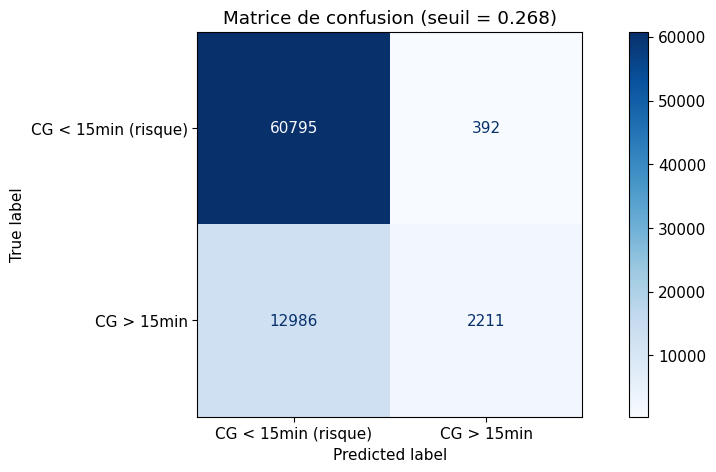

In [66]:
pred = (proba_oot > best_precision_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 15min (risque)', 'CG > 15min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()

# Construction des CHR (stabilité en risque et volume)

In [67]:
from src import binner
  # recharge le module avec les dernières modifications
reload(binner)
Binner = binner.Binner
cols = xgb_vars + ['year','probas',target_col,'points']

train_df = train_data[cols].copy()

test_df = test_data[cols].copy()
oot_df = oot_data[cols].copy()
Bin_train = Binner(X = train_df,cible_col=target_col,date_col='year')
Bin_test = Binner(X = test_df,cible_col=target_col,date_col='year')
Bin_oot = Binner(X = oot_df,cible_col=target_col,date_col='year')


In [68]:
def merge_modalities(bin_instance,mapping, col='CHR' ):
    bin_instance.merge_modalities(
        col=col,
        mapping=mapping
    )

def apply_breaks(bin_instance, breaks,var = 'CHR',upp=None,low=None):
    if var not in bin_instance.X.columns:
        bin_instance.X[var] = np.nan
    bin_instance.X[var] = bin_instance.X[var].astype(str)
    if low is not None and upp is not None:
        mask = (bin_instance.X['probas'] > low) & (bin_instance.X['probas'] <= upp)
    elif low is not None:
        mask = bin_instance.X['probas'] > low
    elif upp is not None:
        mask = bin_instance.X['probas'] <= upp
    else:
        mask = None
    if mask is not None:
        bin_instance.X.loc[mask,var] = pd.cut(
            bin_instance.X.loc[mask,'probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)
    else:
        bin_instance.X[var] = pd.cut(
            bin_instance.X['probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)

In [69]:
import pandas as pd
import numpy as np
import jenkspy

def jenks_prebinning(
    df,
    variable,
    target,
    n_bins=8,
    min_bin_pct=0.01
):
    """
    Jenks pre-binning for IRB (exploratory only)

    Parameters
    ----------
    df : DataFrame (TRAIN uniquement)
    variable : str, variable continue
    target : str, défaut (0/1)
    n_bins : int, nombre max de classes Jenks
    min_bin_pct : float, taille minimale d'un bin

    Returns
    -------
    df_bins : DataFrame avec stats par bin
    breaks : seuils Jenks
    """

    # Séparation missing / non-missing
    df_nm = df[[variable, target]].dropna()
    df_miss = df[df[variable].isna()]

    # Jenks sur non-missing uniquement
    values = df_nm[variable].values

    # Sécurité si peu de valeurs uniques
    n_bins_eff = min(n_bins, len(np.unique(values)) - 1)
    if n_bins_eff < 2:
        raise ValueError("Pas assez de valeurs uniques pour Jenks")

    breaks = jenkspy.jenks_breaks(values, n_classes=n_bins_eff)

    # Application des bins
    df_nm['bin_raw'] = pd.cut(
        df_nm[variable],
        bins=breaks,
        include_lowest=True
    )

    # Stats par bin
    bin_stats = (
        df_nm
        .groupby('bin_raw')[target]
        .agg(['count', 'sum'])
        .rename(columns={'count': 'n_obs', 'sum': 'defaults'})
    )

    bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
    bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()

    # Flag bins trop petits
    bin_stats['small_bin_flag'] = bin_stats['pct_obs'] < min_bin_pct

    # Missing bin (séparé)
    if len(df_miss) > 0:
        miss_defaults = df_miss[target].sum()
        miss_n = len(df_miss)
        miss_dr = miss_defaults / miss_n

        bin_stats.loc['Missing', :] = [
            miss_n,
            miss_defaults,
            miss_dr,
            miss_n / len(df),
            False
        ]

    return bin_stats, breaks



## premier regroupement

In [ ]:
# desc , breaks = jenks_prebinning(df=train_df,
#     variable='probas',target=target_col,n_bins=12,
#     min_bin_pct=0.01)

In [ ]:
breaks = [np.float32(2.3092497e-07),
 np.float32(0.014480316),
 np.float32(0.04405614),
 np.float32(0.09140309),
 np.float32(0.1642518),
 np.float32(0.27787155),
 np.float32(0.43132007),
 np.float32(0.59127015),
 np.float32(0.72720855),
 np.float32(0.83327883),
 np.float32(0.9135624),
 np.float32(0.970386),
 np.float32(0.99999964)]

[np.float32(2.3092497e-07),
 np.float32(0.014480316),
 np.float32(0.04405614),
 np.float32(0.09140309),
 np.float32(0.1642518),
 np.float32(0.27787155),
 np.float32(0.43132007),
 np.float32(0.59127015),
 np.float32(0.72720855),
 np.float32(0.83327883),
 np.float32(0.9135624),
 np.float32(0.970386),
 np.float32(0.99999964)]

In [72]:
desc

,n_obs,defaults,dr,pct_obs,small_bin_flag
bin_raw,,,,,
"(-0.000999769, 0.0145]",198229,24,0.000121,0.577093,False
"(0.0145, 0.0441]",42947,53,0.001234,0.125029,False
"(0.0441, 0.0914]",16134,90,0.005578,0.046970,False
"(0.0914, 0.164]",6942,149,0.021464,0.020210,False
"(0.164, 0.278]",3141,322,0.102515,0.009144,True
"(0.278, 0.431]",1642,715,0.435445,0.004780,True
"(0.431, 0.591]",1525,1290,0.845902,0.004440,True
"(0.591, 0.727]",2117,2057,0.971658,0.006163,True
"(0.727, 0.833]",3424,3408,0.995327,0.009968,True


In [73]:
apply_breaks(Bin_oot, breaks)
apply_breaks(Bin_test, breaks)
apply_breaks(Bin_train, breaks)

In [74]:
train_df.CHR.unique()

array(['(-0.000999769, 0.0145]', '(0.0145, 0.0441]', '(0.833, 0.914]',
       '(0.914, 0.97]', '(0.97, 1.0]', '(0.0914, 0.164]',
       '(0.0441, 0.0914]', '(0.727, 0.833]', '(0.164, 0.278]',
       '(0.431, 0.591]', '(0.278, 0.431]', '(0.591, 0.727]'], dtype=object)

In [82]:
mapping = {
    '(0.97, 1.0]' : '(0.833, 1.0]',
    '(0.914, 0.97]' : '(0.833, 1.0]',
    '(0.833, 0.914]' : '(0.833, 1.0]',

}
merge_modalities(Bin_train, mapping)
merge_modalities(Bin_test, mapping)
merge_modalities(Bin_oot, mapping)

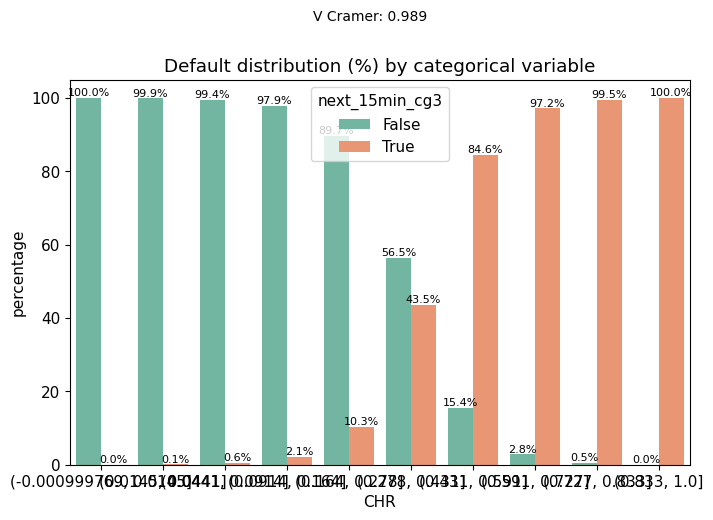

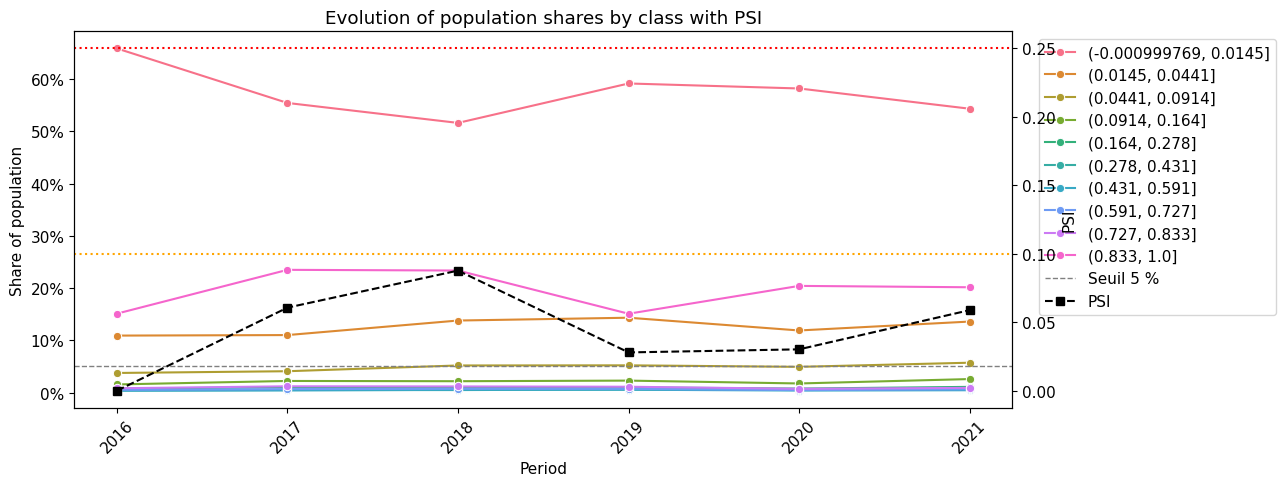

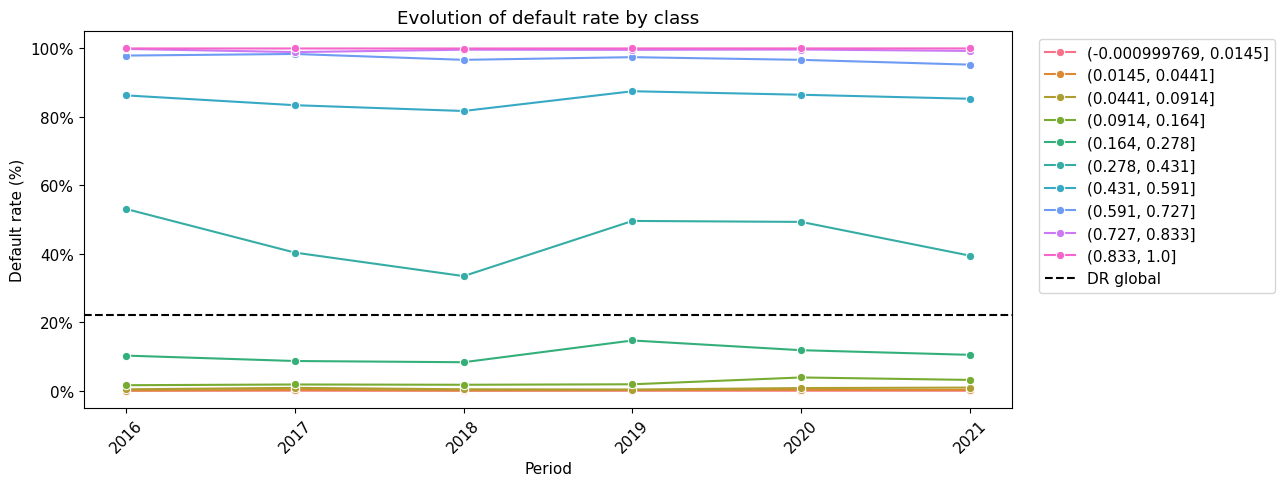

In [83]:
Bin_train.plot_categorical_distribution('CHR')
Bin_train.plot_bin_stability_over_time('CHR')

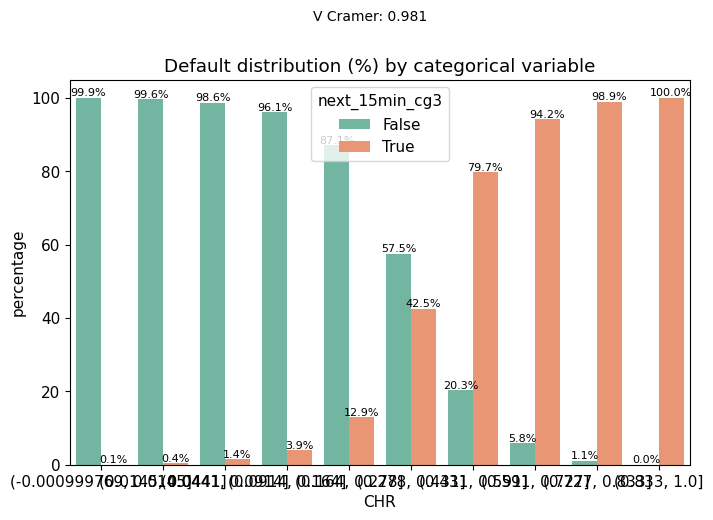

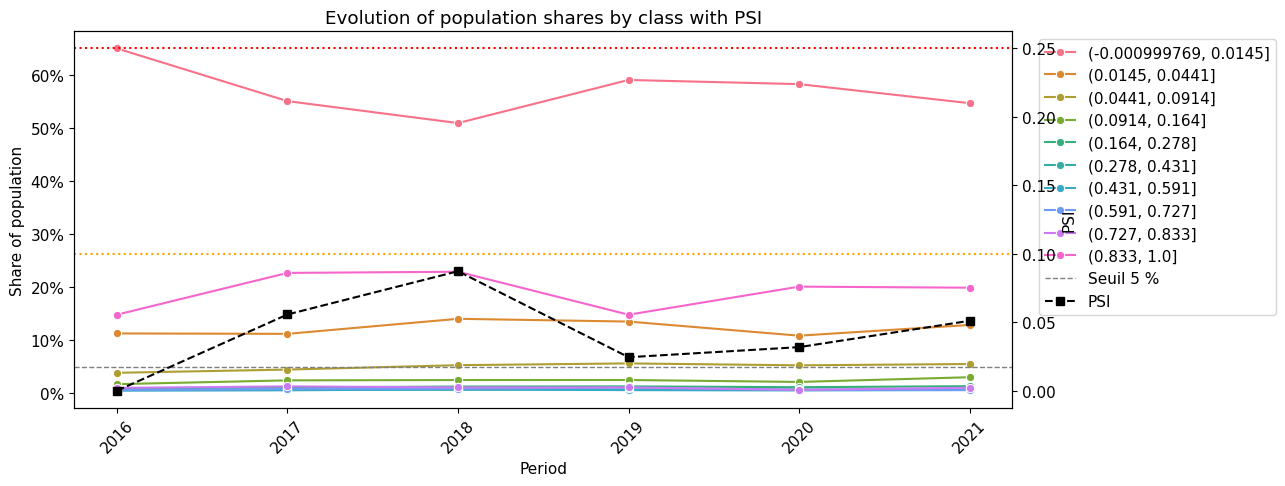

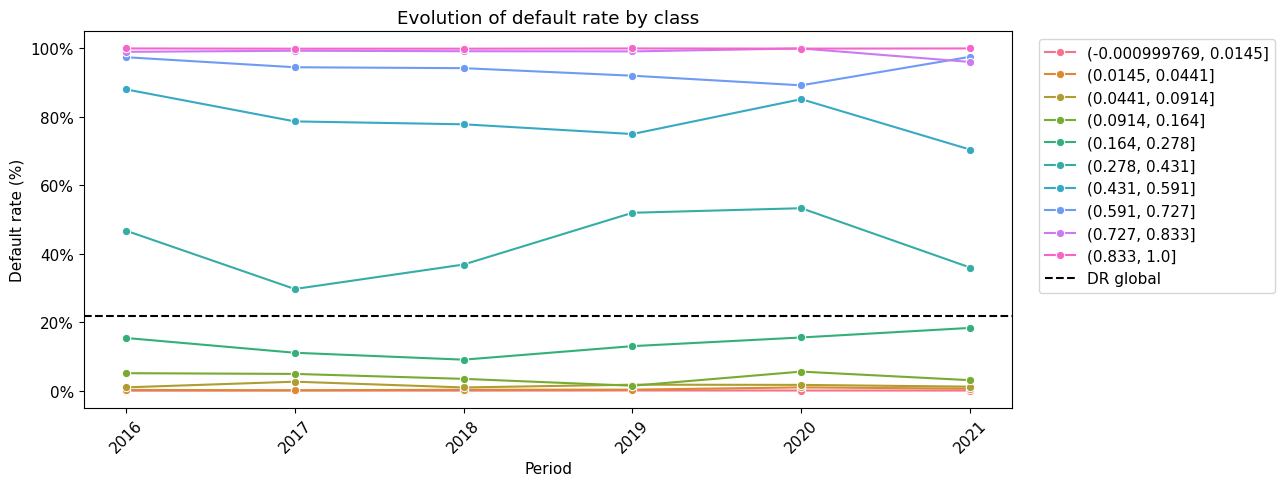

In [84]:
Bin_test.plot_categorical_distribution('CHR')
Bin_test.plot_bin_stability_over_time('CHR')

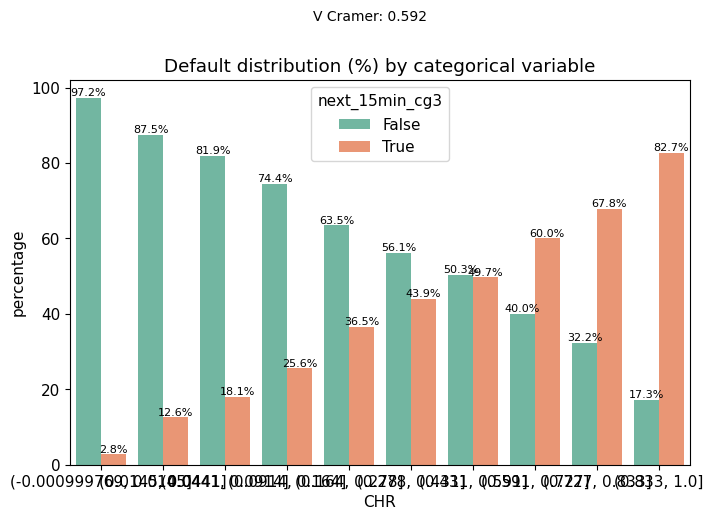

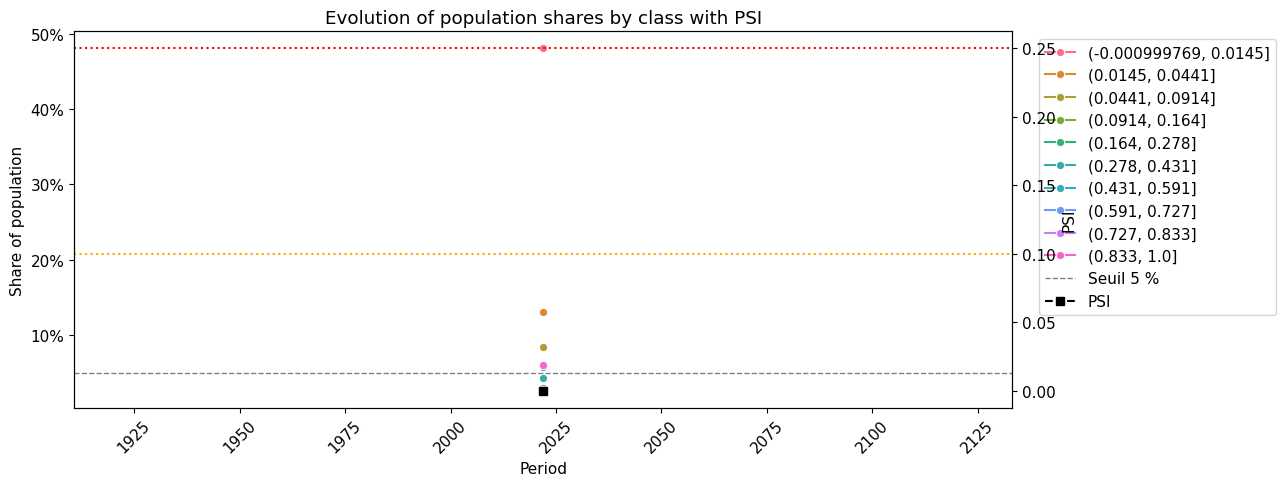

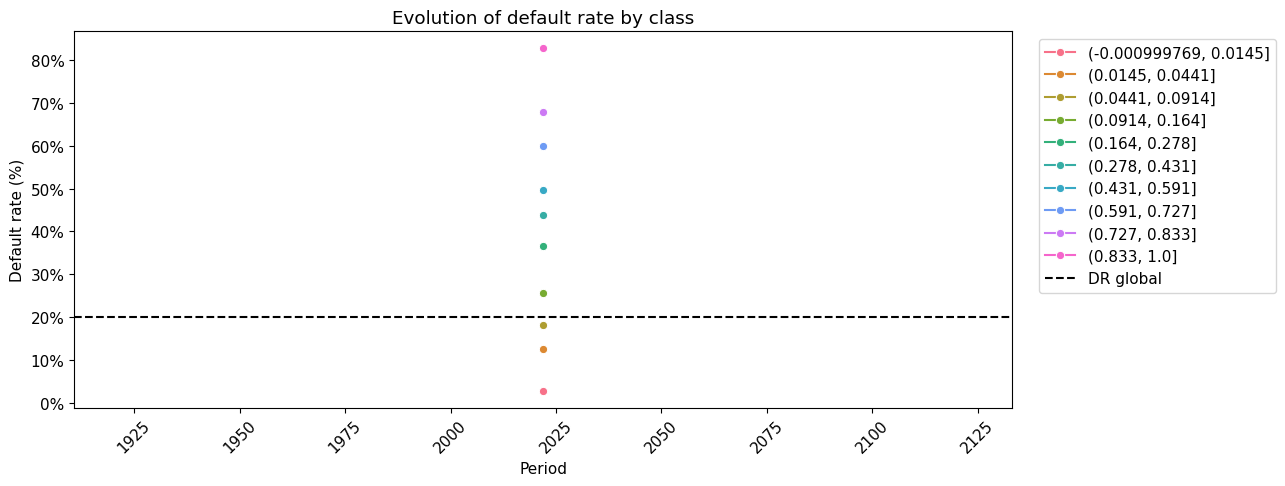

In [85]:
Bin_oot.plot_categorical_distribution('CHR')
Bin_oot.plot_bin_stability_over_time('CHR')

# The probas estimate

In [86]:
calib_df = pd.concat([test_df,oot_df],axis = 0)
calib_df.tail()

,min_dist_10min,min_dist_1min,log_cg_count_10min,log_cg_count_5min,log_count_5min,log_count_10min,log_cg_count_20min,std_azimuth_1min,mean_dist_5min,log_count_20min,...,season,cg_20km,alert_duration,azimuth,azimuth_change,year,probas,next_15min_cg3,points,CHR
76379,3.511937,7.767450,2.708050,2.197225,3.258097,3.688879,2.944439,110.516374,11.491299,4.077537,...,Automne,True,2619.0,268.312897,-4.615669,2022,0.298049,True,298.049011,"(0.278, 0.431]"
76380,3.511937,7.767450,2.708050,2.197225,3.258097,3.713572,2.944439,104.005693,11.531050,4.094345,...,Automne,False,NaN,323.054414,0.777250,2022,0.247831,True,247.831192,"(0.164, 0.278]"
76381,3.511937,7.767450,2.708050,2.197225,3.258097,3.713572,2.995732,21.760263,11.657951,4.110874,...,Automne,True,2651.0,313.683088,34.777050,2022,0.385420,True,385.419586,"(0.278, 0.431]"
76382,3.511937,7.767450,2.772589,2.302585,3.258097,3.713572,3.044522,22.190213,11.809511,4.127134,...,Automne,True,2666.0,321.460089,34.700509,2022,0.346461,True,346.460541,"(0.278, 0.431]"
76383,1.728791,1.728791,2.833213,2.397895,3.295837,3.737670,3.091042,116.570805,11.421791,4.127134,...,Automne,True,2673.0,28.277187,-9.285222,2022,0.987965,True,987.965393,"(0.833, 1.0]"


In [87]:
bin_stats = (
    calib_df
    .groupby('CHR')[[target_col,'probas', 'points']]
    .agg({
        target_col: ['count', 'sum'],
        'probas' : ['min', 'max'],
        'points': ['min', 'max']
    })
)

# Flatten MultiIndex columns
bin_stats.columns = ['n_obs', 'defaults','min_probas', 'max_probas', 'min_points', 'max_points']

bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()
bin_stats


,n_obs,defaults,min_probas,max_probas,min_points,max_points,dr,pct_obs
CHR,,,,,,,,
"(-0.000999769, 0.0145]",85920,1048,3.349116e-07,0.014479,0.000335,14.479023,0.012197,0.529527
"(0.0145, 0.0441]",20620,1296,1.448083e-02,0.044055,14.480826,44.054752,0.062852,0.127082
"(0.0441, 0.0914]",10561,1215,4.405898e-02,0.091402,44.058983,91.402100,0.115046,0.065088
"(0.0914, 0.164]",6586,1265,9.140582e-02,0.164246,91.405823,164.246490,0.192074,0.040590
"(0.164, 0.278]",5326,1723,1.642600e-01,0.277865,164.260010,277.865265,0.323507,0.032824
"(0.278, 0.431]",3838,1677,2.778716e-01,0.431246,277.871613,431.246185,0.436946,0.023654
"(0.431, 0.591]",2794,1531,4.313231e-01,0.591261,431.323059,591.260681,0.547960,0.017219
"(0.591, 0.727]",2615,1780,5.912809e-01,0.727178,591.280884,727.177490,0.680688,0.016116
"(0.727, 0.833]",2880,2219,7.272474e-01,0.833204,727.247437,833.204041,0.770486,0.017750


## 9. Sauvegarde des artefacts du modèle

On sauvegarde dans un unique fichier pickle tous les éléments nécessaires à la mise en production du score :

| Objet | Description |
|---|---|
| `model` | XGBClassifier fitté |
| `vars_to_use` | Liste des features d'entrée |
| `best_params` | Hyperparamètres Optuna |
| `imputer` | SimpleImputer fitté sur train (médianes) |
| `breaks` | Intervalles de discrétisation des scores → CHR |
| `bin_stats` | Taux de risque CG par CHR (calibration test+OOT) |
| `performance` | Résumé AUC / Gini / RP sur train, test et OOT |

In [88]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

artefacts = {
    'model'       : model_xgb,
    'vars_to_use' : xgb_vars,
    'best_params' : params,
    'imputer'     : imputer,
    'breaks'      : breaks,
    'bin_stats'   : bin_stats,
    'performance' : {
        'train': {'auc': auc_train, 'gini': gini_train},
        'test' : {'auc': auc_test,  'auc_pr': auc_pr_test, 'rp': rp},
        'oot'  : {'auc': auc_oot,   'auc_pr': auc_pr_oot,  'rp': rp_o},
    },
}

save_path = '../models/xgb_cg15_3km_artefacts.pkl'
joblib.dump(artefacts, save_path)
print(f'Artefacts sauvegardes dans {save_path}')
print(f'  Variables      : {len(xgb_vars)}')
print(f'  Hyperparametres: {list(params.keys())}')
print(f'  Breaks CHR     : {breaks}')
print(f'  ROC AUC train  : {auc_train:.4f}  |  test : {auc_test:.4f}  |  OOT : {auc_oot:.4f}')


Artefacts sauvegardes dans ../models/xgb_cg15_3km_artefacts.pkl
  Variables      : 37
  Hyperparametres: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_alpha', 'reg_lambda']
  Breaks CHR     : [np.float32(2.3092497e-07), np.float32(0.014480316), np.float32(0.04405614), np.float32(0.09140309), np.float32(0.1642518), np.float32(0.27787155), np.float32(0.43132007), np.float32(0.59127015), np.float32(0.72720855), np.float32(0.83327883), np.float32(0.9135624), np.float32(0.970386), np.float32(0.99999964)]
  ROC AUC train  : 0.9995  |  test : 0.9984  |  OOT : 0.8753
